# Phase 3: Financial Decision Engine & Deposit-at-Risk Framework

## Executive Summary & Business Economics
In banking, machine learning models that optimize purely for F1-score or statistical logloss fail to maximize business value.
**Not all customer churns carry equal financial loss:**
- Losing a customer with **€0** in deposits costs little in interest margin.
- Losing a customer with **€150,000** in deposits costs **€4,200 annually in Net Interest Margin (NIM)**.

In this phase, we build the **Financial Decision Engine**:
1. **Quantify Total Deposits at Risk (€)**: Total balance held by predicted churners.
2. **Calculate Net Interest Margin (NIM) Revenue Impact**: Annual revenue generated by deposits ($2.8\%$ baseline NIM rate).
3. **Financial Cost-Benefit Optimization**: Optimize risk cutoff threshold $p^*$ to maximize net annual profit saved after campaign intervention costs.
4. **4-Tier Customer Segmentation Matrix**: Classify customers into actionable retention quadrants.

In [1]:
import sys
from pathlib import Path

# Ensure project root is in sys.path
root_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import ARTIFACTS_DIR, FIGURES_DIR, PROCESSED_DATA_PATH, ANNUAL_NIM_RATE, HIGH_BALANCE_THRESHOLD
from src.business_optimizer import (
    optimize_decision_threshold,
    segment_portfolio_customers,
    compute_portfolio_deposit_risk,
    evaluate_retention_economics,
)

print("Financial decision engine environment ready.")

Financial decision engine environment ready.


## 1. Load Calibrated Model & Score Portfolio Holdout

In [2]:
# Load holdout test dataset and serialized calibrated champion pipeline
from sklearn.model_selection import train_test_split
from src.preprocess import load_and_clean_data, split_features_and_target

df_clean = load_and_clean_data(validate=True)
X, y = split_features_and_target(df_clean)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

calibrated_model = joblib.load(ARTIFACTS_DIR / "champion_model.pkl")
test_probas = calibrated_model.predict_proba(X_test)[:, 1]

print(f"Scored {len(X_test):,} holdout customers.")
print(f"Predicted Churn Risk Range: [{test_probas.min():.4f}, {test_probas.max():.4f}]")

Scored 2,000 holdout customers.
Predicted Churn Risk Range: [0.0011, 0.9916]


## 2. Portfolio-Level Deposit Risk & Campaign Economics

In [3]:
portfolio_risk = compute_portfolio_deposit_risk(X_test, test_probas, threshold=0.10)

print("=" * 60)
print("EXECUTIVE PORTFOLIO DEPOSIT RISK OVERVIEW (2,000 Customers)")
print("=" * 60)
print(f"Total Portfolio Deposits:      €{portfolio_risk['total_portfolio_deposits']:,.2f}")
print(f"Deposits at Risk of Churn:     €{portfolio_risk['deposits_at_risk']:,.2f} ({portfolio_risk['deposits_at_risk']/portfolio_risk['total_portfolio_deposits']:.1%})")
print(f"Annual NIM at Risk (2.8%):     €{portfolio_risk['annual_nim_at_risk']:,.2f}")
print(f"Total Targeted Customers:      {portfolio_risk['total_targeted_customers']:,}")
print(f"Total Campaign Cost:           €{portfolio_risk['total_campaign_cost']:,.2f}")
print(f"Expected Net NIM Saved:        €{portfolio_risk['expected_net_nim_saved']:,.2f}")
print(f"Campaign Projected ROI:        {portfolio_risk['campaign_roi_pct']:,.1f}%")
print("=" * 60)

EXECUTIVE PORTFOLIO DEPOSIT RISK OVERVIEW (2,000 Customers)
Total Portfolio Deposits:      €153,301,495.27
Deposits at Risk of Churn:     €36,708,806.10 (23.9%)
Annual NIM at Risk (2.8%):     €1,027,846.57
Total Targeted Customers:      407
Total Campaign Cost:           €47,050.00
Expected Net NIM Saved:        €614,436.43
Campaign Projected ROI:        1,305.9%


## 3. Financial Threshold Optimization ($p^*$) Across Deposit Curves

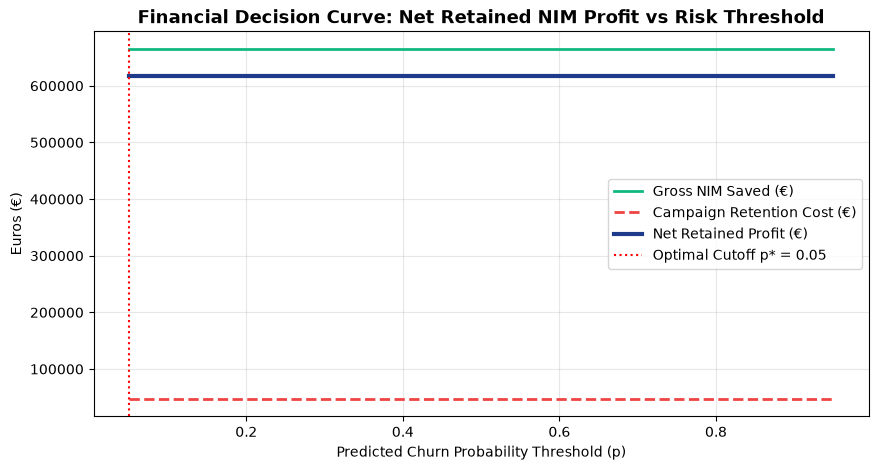

In [4]:
balances = X_test["Balance"].values
opt_results = optimize_decision_threshold(y_test.values, test_probas, balances)

tc = opt_results["threshold_curve"]
plt.figure(figsize=(10, 5))
plt.plot(tc["thresholds"], tc["gross_nim_saved"], label="Gross NIM Saved (€)", color="#10B981", lw=2)
plt.plot(tc["thresholds"], tc["retention_costs"], label="Campaign Retention Cost (€)", color="#EF4444", lw=2, linestyle="--")
plt.plot(tc["thresholds"], tc["net_profits"], label="Net Retained Profit (€)", color="#1E3A8A", lw=3)
plt.axvline(opt_results["optimal_threshold"], color="red", linestyle=":", label=f"Optimal Cutoff p* = {opt_results['optimal_threshold']:.2f}")

plt.title("Financial Decision Curve: Net Retained NIM Profit vs Risk Threshold", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Churn Probability Threshold (p)")
plt.ylabel("Euros (€)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. The 4-Tier Strategic Retention Matrix

Every customer is categorized into one of 4 quadrants based on their **Deposit Balance (€)** and **Calibrated Churn Probability**:

In [5]:
segmented_holdout = segment_portfolio_customers(X_test, test_probas, threshold=0.10)

tier_counts = segmented_holdout["RetentionTier"].value_counts().reset_index()
tier_counts.columns = ["Strategic Retention Quadrant", "Customer Count"]
tier_counts

,Strategic Retention Quadrant,Customer Count
0,Tier 3: High Value / Low Risk (Wealth Cross-Sell),963
1,Tier 4: Low Value / Low Risk (Standard Service),630
2,Tier 1: High Value / High Risk (RM VIP Outreach),295
3,Tier 2: Low Value / High Risk (Digital Offer),112


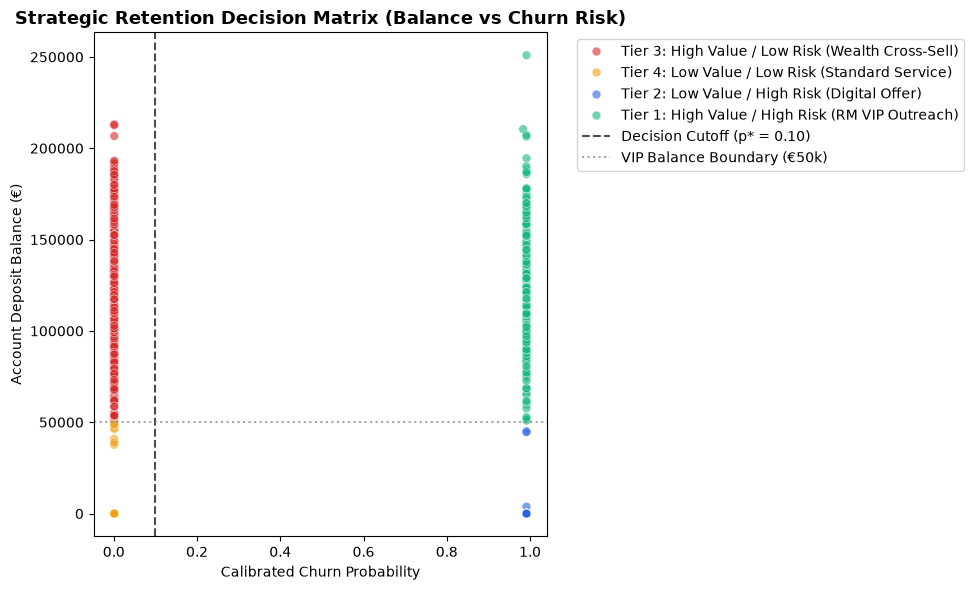

In [6]:
# Scatter plot of the 4 Retention Quadrants
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=segmented_holdout,
    x="ChurnProbability",
    y="Balance",
    hue="RetentionTier",
    palette=["#DC2626", "#F59E0B", "#2563EB", "#10B981"],
    alpha=0.6,
    s=40
)
plt.axvline(0.10, color="black", linestyle="--", alpha=0.7, label="Decision Cutoff (p* = 0.10)")
plt.axhline(HIGH_BALANCE_THRESHOLD, color="gray", linestyle=":", alpha=0.7, label="VIP Balance Boundary (€50k)")
plt.title("Strategic Retention Decision Matrix (Balance vs Churn Risk)", fontsize=13, fontweight="bold")
plt.xlabel("Calibrated Churn Probability")
plt.ylabel("Account Deposit Balance (€)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()